<a href="https://colab.research.google.com/github/MostaryKhatun/Dengue_infection/blob/main/GSE28405_DataPreprocess.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data_Preprocessing


 STEP 1: Upload the Files

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving GSE18090_deg.txt to GSE18090_deg.txt
Saving GSE18090_series_matrix.txt to GSE18090_series_matrix.txt
Saving target.csv to target.csv


In [ ]:
import os
import csv
import numpy as np
import pandas as pd


Covert test to csv

In [ ]:
def convert_txt_to_csv(input_file, output_file, delimiter='\t'):
    """
    Converts a text file to a CSV file.

    Parameters:
    - input_file (str): Path to the input text file.
    - output_file (str): Path to the output CSV file.
    - delimiter (str): Delimiter used in the input text file (default is tab-delimited).
    """
    try:
        with open(input_file, 'r', newline='') as infile:
            reader = csv.reader(infile, delimiter=delimiter)
            with open(output_file, 'w', newline='') as outfile:
                writer = csv.writer(outfile)
                for row in reader:
                    writer.writerow(row)
        print(f"File '{input_file}' has been successfully converted to '{output_file}'.")
    except Exception as e:
        print(f"An error occurred while converting '{input_file}': {e}")

copy adj.p.value gene

In [ ]:
def merge_csv_files(
    first_csv_path,
    second_csv_path,
    output_csv_path,
    first_key_column,
    second_key_column,
    columns_to_copy,
    delimiter=','
):
    # Check if input files exist
    if not os.path.isfile(first_csv_path):
        print(f"Error: The file '{first_csv_path}' does not exist.")
        return
    if not os.path.isfile(second_csv_path):
        print(f"Error: The file '{second_csv_path}' does not exist.")
        return

    # Read the first CSV and create a mapping from key to desired columns
    first_data = {}
    try:
        with open(first_csv_path, 'r', newline='', encoding='utf-8') as first_file:
            reader = csv.DictReader(first_file, delimiter=delimiter)
            if first_key_column not in reader.fieldnames:
                print(f"Error: '{first_key_column}' not found in the first CSV file headers.")
                return
            for row in reader:
                key = row.get(first_key_column)
                if key is None:
                    continue
                extracted = {col: row.get(col, "") for col in columns_to_copy}
                first_data[key] = extracted
    except Exception as e:
        print(f"Error reading '{first_csv_path}': {e}")
        return

    # Read the second CSV and merge data
    try:
        with open(second_csv_path, 'r', newline='', encoding='utf-8') as second_file, \
             open(output_csv_path, 'w', newline='', encoding='utf-8') as output_file:

            reader = csv.DictReader(second_file, delimiter=delimiter)
            second_fieldnames = reader.fieldnames
            if second_fieldnames is None:
                print(f"Error: The second CSV file '{second_csv_path}' is empty or missing headers.")
                return
            if second_key_column not in second_fieldnames:
                print(f"Error: '{second_key_column}' not found in the second CSV file headers.")
                return

            # Insert new columns after the first column
            insert_position = 1
            new_fieldnames = second_fieldnames[:insert_position] + columns_to_copy + second_fieldnames[insert_position:]
            writer = csv.DictWriter(output_file, fieldnames=new_fieldnames, delimiter=delimiter)
            writer.writeheader()

            for row in reader:
                key = row.get(second_key_column)
                if key is None:
                    writer.writerow(row)
                    continue

                additional_data = first_data.get(key, {col: "" for col in columns_to_copy})
                new_row = {**row}
                # Insert additional_data after the first column
                for col in columns_to_copy:
                    new_row[col] = additional_data.get(col, "")
                # Ensure the order of columns
                ordered_row = {field: new_row.get(field, "") for field in new_fieldnames}
                writer.writerow(ordered_row)

    except Exception as e:
        print(f"Error processing files: {e}")
        return

    print(f"Files have been successfully merged into '{output_csv_path}'.")

perform system biology:Gene regularator network

In [ ]:
def perform_analysis(file_path, output_cleaned_file, report_file):
    """
    Performs data analysis on the given CSV file.

    Parameters:
    - file_path (str): Path to the input CSV file.
    - output_cleaned_file (str): Path to save the cleaned filtered data.
    - report_file (str): Path to save the analysis report.
    """
    data = pd.read_csv(file_path)

    # Get the number of columns and rows
    num_columns = data.shape[1]
    num_rows = data.shape[0]

    # Print column names
    column_names = data.columns.tolist()
    print("Column Names:")
    for col in column_names:
        print(f"- {col}")

    # Take column name and threshold as input from the user
    column_name = input("Enter the column name for analysis: ").strip()
    if column_name not in column_names:
        print(f"Error: Column '{column_name}' does not exist in the data.")
        return

    # Calculate statistics for the column
    mean_value = data[column_name].mean()
    median_value = data[column_name].median()
    mode_value = data[column_name].mode()[0] if not data[column_name].mode().empty else None
    std_dev = data[column_name].std()
    min_value = data[column_name].min()
    max_value = data[column_name].max()

    print(f"Mean: {mean_value}\nMax: {max_value}")

    try:
        threshold = float(input("Enter the threshold value: ").strip())
    except ValueError:
        print("Invalid threshold value.")
        return

    # Filter the data based on the input threshold
    filtered_data = data[data[column_name] < threshold]
    filtered_num_rows = filtered_data.shape[0]

    # Identify and remove rows with any blank (NaN) values
    blank_rows = filtered_data[filtered_data.isna().any(axis=1)].shape[0]
    filtered_data_cleaned = filtered_data.dropna()

    # Save the cleaned filtered data to a new CSV file
    filtered_data_cleaned.to_csv(output_cleaned_file, index=False)

    # Generate a report and save it to a text file
    report = f"""
CSV File Analysis Report
------------------------

Number of Columns: {num_columns}
Number of Rows: {num_rows}

Column Names:
{', '.join(column_names)}

Selected Column: {column_name}

Statistics for {column_name}:
- Mean: {mean_value}
- Median: {median_value}
- Mode: {mode_value}
- Standard Deviation: {std_dev}
- Minimum: {min_value}
- Maximum: {max_value}

Filtering Data:
- Threshold: {threshold}
- Rows after filtering: {filtered_num_rows}

Blank Rows:
- Number of Rows with Blanks: {blank_rows}
- Total Rows after removing blank rows: {filtered_data_cleaned.shape[0]}

Cleaned Filtered Data saved to: {output_cleaned_file}
"""
    with open(report_file, 'w') as report_f:
        report_f.write(report)

    print(f"Report generated and saved to '{report_file}'")
    print(f"Cleaned data saved to '{output_cleaned_file}'")

Transpose Matrix

In [ ]:
def transpose_data(input_file, output_file):
    """
    Transposes the data from the input CSV file after removing the first three columns.

    Parameters:
    - input_file (str): Path to the input CSV file.
    - output_file (str): Path to save the transposed data.
    """
    data = pd.read_csv(input_file)
    # Remove the first three columns
    data = data.iloc[:, 3:]
    # Transpose the DataFrame
    transposed_data = data.T
    # Save the transposed DataFrame
    transposed_data.to_csv(output_file, header=False, index=True)
    print(f"Transposed data saved to '{output_file}'")

Adding the lavel

In [ ]:
def add_target_column(transposed_file, target_file, output_file):
    """
    Adds a 'target' column to the transposed data based on the target genes.

    Parameters:
    - transposed_file (str): Path to the transposed CSV file.
    - target_file (str): Path to the CSV file containing target genes.
    - output_file (str): Path to save the labeled data.
    """
    # Load the transposed data
    df_transposed = pd.read_csv(transposed_file)
    # Load the target genes
    target_genes = pd.read_csv(target_file, header=None, names=['Gene.symbol'])['Gene.symbol'].str.strip()
    # Add a 'target' column initialized to 1
    df_transposed['target'] = 1
    # Remove leading/trailing spaces from 'Gene.symbol'
    df_transposed['Gene.symbol'] = df_transposed['Gene.symbol'].str.strip()
    # Update 'target' to 0 where 'Gene.symbol' matches any value in target_genes
    df_transposed.loc[df_transposed['Gene.symbol'].isin(target_genes), 'target'] = 0
    # Remove the 'Gene.symbol' column
    df_transposed = df_transposed.iloc[:, 1:]
    # Save the updated DataFrame
    df_transposed.to_csv(output_file, index=False)
    print(f"Labeled data saved to '{output_file}'")

main

In [ ]:
# Dynamic dataset name
dataset_name = input("Enter the dataset name (e.g., 'GSE62792'): ").strip()

Enter the dataset name (e.g., 'GSE62792'): GSE18090


In [ ]:
# File paths
deg_input_file = f'{dataset_name}_deg.txt'
metrix_input_file = f'{dataset_name}_series_matrix.txt'
deg_output_file = f'{dataset_name}_deg.csv'
metrix_output_file = f'{dataset_name}_series_matrix.csv'
merged_output_file = f'{dataset_name}_series_matrix_with_pvalues.csv'
cleaned_file_path = f'filtered_data_{dataset_name}.csv'
report_file_path = f'analysis_report_{dataset_name}.txt'
transposed_file = f'{dataset_name}_matrix_Transpose.csv'
labeled_output_file = f'{dataset_name}_matrix_Transpose_labeled.csv'
target_file = 'target.csv'  # Ensure this file exists in your working directory

In [ ]:
# Step 1: Convert text files to CSV
convert_txt_to_csv(deg_input_file, deg_output_file)
convert_txt_to_csv(metrix_input_file, metrix_output_file)

File 'GSE18090_deg.txt' has been successfully converted to 'GSE18090_deg.csv'.
File 'GSE18090_series_matrix.txt' has been successfully converted to 'GSE18090_series_matrix.csv'.


In [ ]:
# Step 2: Merge CSV files
merge_csv_files(
    first_csv_path=deg_output_file,
    second_csv_path=metrix_output_file,
    output_csv_path=merged_output_file,
    first_key_column='ID',
    second_key_column='ID_REF',
    columns_to_copy=['adj.P.Val', 'P.Value', 'Gene.symbol'],
    delimiter=','
)

Files have been successfully merged into 'GSE18090_series_matrix_with_pvalues.csv'.


In [ ]:
# Step 3: Perform data analysis
perform_analysis(
    file_path=merged_output_file,
    output_cleaned_file=cleaned_file_path,
    report_file=report_file_path
)

Column Names:
- ID_REF
- adj.P.Val
- P.Value
- Gene.symbol
- GSM452235
- GSM452236
- GSM452237
- GSM452238
- GSM452239
- GSM452240
- GSM452241
- GSM452242
- GSM452243
- GSM452244
- GSM452245
- GSM452246
- GSM452247
- GSM452248
- GSM452249
- GSM452250
- GSM452251
- GSM452252
- GSM452253
- GSM452254
- GSM452255
- GSM452256
- GSM452257
- GSM452258
- GSM452259
- GSM452260
Enter the column name for analysis: P.Value
Mean: 0.40763450387111116
Max: 1.0
Enter the threshold value: 0.25
Report generated and saved to 'analysis_report_GSE18090.txt'
Cleaned data saved to 'filtered_data_GSE18090.csv'


In [ ]:
# Step 4: Transpose the data
transpose_data(
    input_file=cleaned_file_path,
    output_file=transposed_file
)

Transposed data saved to 'GSE18090_matrix_Transpose.csv'


In [ ]:
# # Step 5: Add the target column
# add_target_column(
#     transposed_file=transposed_file,
#     target_file=target_file,
#     output_file=labeled_output_file
# )

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#Common_gene

In [ ]:
import pandas as pd
import os

# =========================
# FUNCTION (MUST RUN FIRST)
# =========================
def get_gene_set(path):
    df = pd.read_csv(path)

    # clean column names
    df.columns = df.columns.str.strip()

    # get all columns except target
    genes = (
        pd.Index(df.columns)
        .str.upper()
        .str.strip()
    )

    # remove Sample and target columns if present
    genes = genes.difference(["SAMPLE", "TARGET"])

    return set(genes)


# =========================
# COMMON GENE PIPELINE
# =========================
base_path = "/content/drive/MyDrive/Dengue_level_datasets/datasets"

datasets = [
    "GSE16463_matrix_Transpose_labeled.csv",
    "GSE18090_matrix_Transpose_labeled.csv",
    "GSE28405_matrix_Transpose_labeled.csv",
    "GSE28985_matrix_Transpose_labeled.csv",
    "GSE51808_matrix_Transpose_labeled.csv",
    "GSE84331_matrix_Transpose_labeled.csv"
]

gene_sets = []

for ds in datasets:
    path = os.path.join(base_path, ds)

    genes = get_gene_set(path)

    print(ds, "genes:", len(genes))
    gene_sets.append(genes)

# =========================
# FIND COMMON GENES
# =========================
common_genes = set.intersection(*gene_sets)

print("\n✅ FINAL COMMON GENES:", len(common_genes))

# =========================
# SAVE COMMON GENES
# =========================
common_genes_df = pd.DataFrame(
    sorted(common_genes),
    columns=["Gene.symbol"]
)

output_file = os.path.join(base_path, "Common_Genes.csv")
common_genes_df.to_csv(output_file, index=False)

print("✅ Common genes saved to:", output_file)

In [ ]:
# ==========================================
# Install package (run once)
# ==========================================
!pip install -q venny4py

# ==========================================
# Import library
# ==========================================
from venny4py.venny4py import *

# ==========================================
# Create full dictionary
# ==========================================
gene_dict = {
    ds.replace("_matrix_Transpose_labeled.csv", ""): genes
    for ds, genes in zip(datasets, gene_sets)
}

# ==========================================
# Choose ANY 4 datasets
# ==========================================
# selected_datasets = [
#     "GSE16463",
#     "GSE18090",
#     "GSE51808",
#     "GSE84331"
# ]
selected_datasets = [
    "GSE28405",
    "GSE28985",
    "GSE51808",
    "GSE84331"
]

# Create dictionary for only these 4 datasets
selected_gene_dict = {
    ds: gene_dict[ds]
    for ds in selected_datasets
}

# Check loaded datasets
print("Datasets loaded:")
for ds, genes in selected_gene_dict.items():
    print(ds, len(genes))

# ==========================================
# Draw Venn Diagram
# ==========================================
venny4py(
    sets=selected_gene_dict,
    colors=[
        "#FF9999",  # GSE16463
        "#66B3FF",  # GSE18090
        "#99FF99",  # GSE51808
        "#FFD700"   # GSE84331
    ]
)

#

#ComBat Batch Effect Correction Code (Train/Test setup)


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
!pip install pandas numpy scanpy anndata

In [2]:
# ==========================================
# Step 2: Import
# ==========================================
import pandas as pd
import numpy as np
import scanpy as sc
import anndata as ad

# ==========================================
# Step 3: Load datasets
# ==========================================
base_path = "/content/drive/MyDrive/Dengue_level_datasets/datasets"

train_files = [
    "GSE51808_matrix_Transpose_labeled.csv",
    "GSE84331_matrix_Transpose_labeled.csv",
    "GSE18090_matrix_Transpose_labeled.csv",
    "GSE16463_matrix_Transpose_labeled.csv",
    "GSE28985_matrix_Transpose_labeled.csv"
]

test_file = "GSE28405_matrix_Transpose_labeled.csv"

# ==========================================
# Step 4: Load + merge TRAIN
# ==========================================
train_dfs = []

for file in train_files:
    df = pd.read_csv(f"{base_path}/{file}")
    df.columns = df.columns.str.strip()

    df["Batch"] = file
    train_dfs.append(df)

train_df = pd.concat(train_dfs, axis=0, ignore_index=True)

print("Train shape:", train_df.shape)

# ==========================================
# Step 5: Load TEST
# ==========================================
test_df = pd.read_csv(f"{base_path}/{test_file}")
test_df.columns = test_df.columns.str.strip()
test_df["Batch"] = "TEST"

print("Test shape:", test_df.shape)

# ==========================================
# Step 6: Merge all
# ==========================================
combined_df = pd.concat([train_df, test_df], axis=0, ignore_index=True)

print("Combined shape:", combined_df.shape)

# ==========================================
# ✔️ VERY IMPORTANT STEP (FIX TARGET HERE)
# ==========================================

# target আলাদা করো BEFORE ComBat
y = combined_df["target"].astype(int)     # keep 0/1 SAFE
batch = combined_df["Batch"]

# expression matrix only
X = combined_df.drop(columns=["target", "Batch"])

# numeric conversion
X = X.apply(pd.to_numeric, errors="coerce").fillna(0)

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())

# ==========================================
# Step 7: ComBat (ONLY X)
# ==========================================
adata = ad.AnnData(X)
adata.obs["batch"] = batch.values

sc.pp.combat(adata, key="batch")

X_corrected = pd.DataFrame(
    adata.X,
    columns=X.columns
)

print("Batch correction done!")

# ==========================================
# Step 8: Reattach target (NO CHANGE)
# ==========================================
final_df = X_corrected.copy()
final_df["target"] = y.values
final_df["Batch"] = batch.values

print("Final shape:", final_df.shape)

# ==========================================
# Step 9: Separate train/test
# ==========================================
train_corrected = final_df[final_df["Batch"] != "TEST"].copy()
test_corrected  = final_df[final_df["Batch"] == "TEST"].copy()

print("Train corrected:", train_corrected.shape)
print("Test corrected:", test_corrected.shape)

# ==========================================
# Step 10: Save files
# ==========================================
output_path = base_path + "/combined_combat_corrected.csv"
train_path  = base_path + "/train_combat_corrected.csv"
test_path   = base_path + "/test_combat_corrected.csv"

final_df.to_csv(output_path, index=False)
train_corrected.to_csv(train_path, index=False)
test_corrected.to_csv(test_path, index=False)

print("Saved successfully!")

/tmp/ipykernel_1451/1620545274.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Batch"] = file
/tmp/ipykernel_1451/1620545274.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Batch"] = file
/tmp/ipykernel_1451/1620545274.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Batch"]

Train shape: (214, 33155)


/tmp/ipykernel_1451/1620545274.py:45: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df["Batch"] = "TEST"


Test shape: (119, 9977)
Combined shape: (333, 33622)
X shape: (333, 33620)
y distribution:
 target
1    271
0     62
Name: count, dtype: int64


/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_combat.py:349: RuntimeWarning: divide by zero encountered in divide
  (abs(g_new - g_old) / g_old).max(), (abs(d_new - d_old) / d_old).max()


Batch correction done!
Final shape: (333, 33622)
Train corrected: (214, 33622)
Test corrected: (119, 33622)
Saved successfully!


In [3]:
print(train_corrected.columns[-5:])  # last 5 columns
print("target unique:", train_corrected["target"].unique())
print(train_corrected["target"].value_counts())

Index(['OPN1LW', 'SLC17A7', 'TAP2.2', 'target', 'Batch'], dtype='str')
target unique: [1 0]
target
1    178
0     36
Name: count, dtype: int64


In [4]:
print("\nTrain target distribution:")
print(train_corrected["target"].value_counts())

print("\nTest target distribution:")
print(test_corrected["target"].value_counts())


Train target distribution:
target
1    178
0     36
Name: count, dtype: int64

Test target distribution:
target
1    93
0    26
Name: count, dtype: int64


#Before vs After ComBat (PCA Figure)

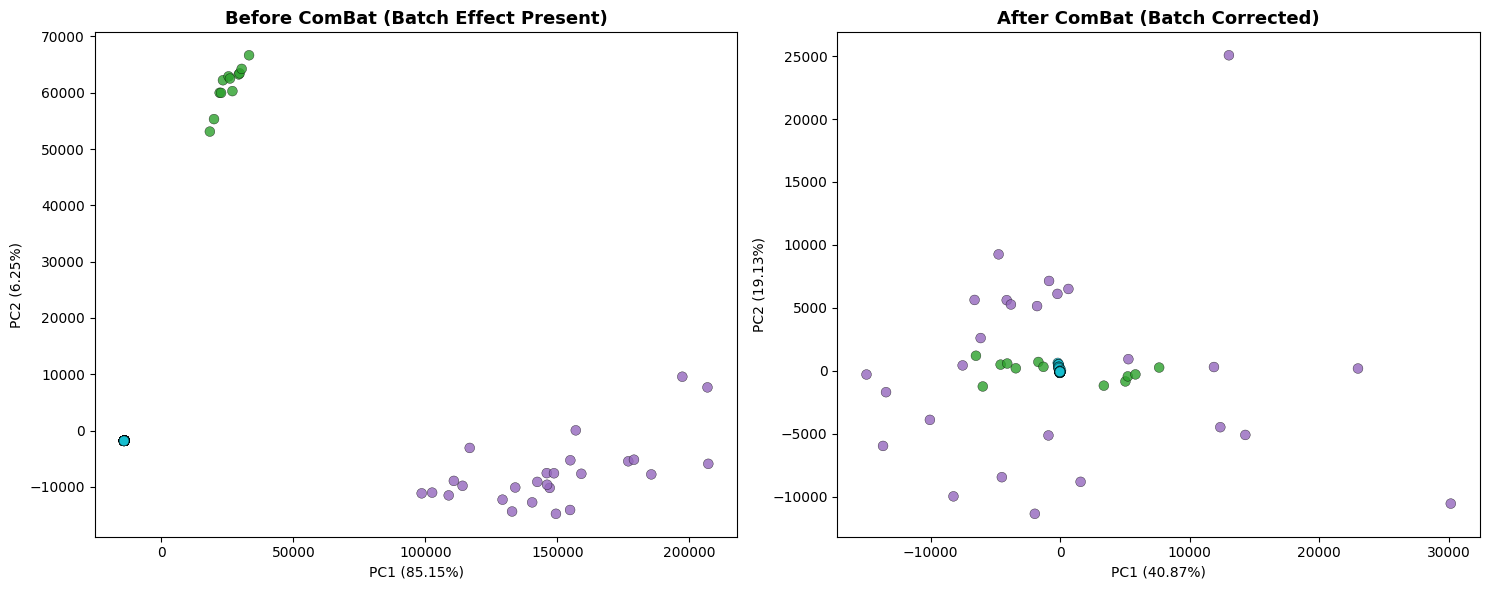

In [11]:
# ==========================================
# PCA Before vs After ComBat
# ==========================================
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

# ==========================================
# PCA Function
# ==========================================
def plot_pca(data, batch_labels, title, ax):

    pca = PCA(n_components=2)

    pcs = pca.fit_transform(data)

    scatter = ax.scatter(
        pcs[:, 0],
        pcs[:, 1],
        c=pd.factorize(batch_labels)[0],
        cmap="tab10",
        s=50,
        alpha=0.8,
        edgecolors="k",
        linewidth=0.3
    )

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")

# ==========================================
# Figure
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15,6))

# Before ComBat
plot_pca(
    X,
    batch,
    "Before ComBat (Batch Effect Present)",
    axes[0]
)

# After ComBat
plot_pca(
    X_corrected,
    batch,
    "After ComBat (Batch Corrected)",
    axes[1]
)

plt.tight_layout()
plt.show()

#Batch Effect Quantification Score (Before vs After)

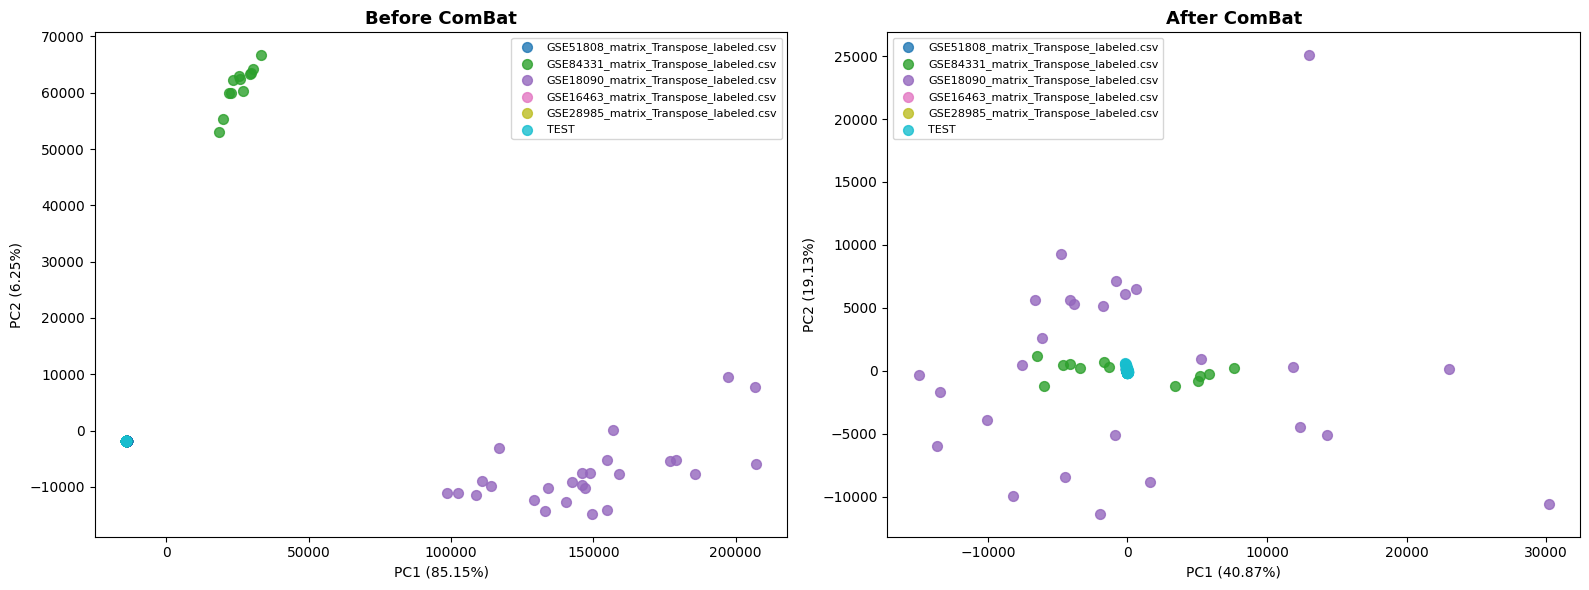

In [12]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_pca(data, batch_labels, title, ax):

    pca = PCA(n_components=2)
    pcs = pca.fit_transform(data)

    batches = pd.unique(batch_labels)
    colors = plt.cm.tab10(np.linspace(0,1,len(batches)))

    for color, b in zip(colors, batches):
        idx = batch_labels == b
        ax.scatter(
            pcs[idx,0],
            pcs[idx,1],
            label=b,
            s=50,
            alpha=0.8,
            color=color
        )

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1,2, figsize=(16,6))

plot_pca(
    X,
    batch,
    "Before ComBat",
    axes[0]
)

plot_pca(
    X_corrected,
    batch,
    "After ComBat",
    axes[1]
)

plt.tight_layout()
plt.show()

In [13]:
# ==========================================
# Batch Effect Quantification
# ==========================================
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

# Convert batch labels to integers
batch_labels = batch.astype("category").cat.codes

# ------------------------------------------
# BEFORE ComBat
# ------------------------------------------
sil_before = silhouette_score(X, batch_labels)
ch_before = calinski_harabasz_score(X, batch_labels)
db_before = davies_bouldin_score(X, batch_labels)

# ------------------------------------------
# AFTER ComBat
# ------------------------------------------
sil_after = silhouette_score(X_corrected, batch_labels)
ch_after = calinski_harabasz_score(X_corrected, batch_labels)
db_after = davies_bouldin_score(X_corrected, batch_labels)

# ------------------------------------------
# Results
# ------------------------------------------
print("="*55)
print("      Batch Effect Quantification")
print("="*55)

print(f"Silhouette Score")
print(f"  Before ComBat : {sil_before:.4f}")
print(f"  After ComBat  : {sil_after:.4f}")

print()

print(f"Calinski-Harabasz Index")
print(f"  Before ComBat : {ch_before:.2f}")
print(f"  After ComBat  : {ch_after:.2f}")

print()

print(f"Davies-Bouldin Index")
print(f"  Before ComBat : {db_before:.4f}")
print(f"  After ComBat  : {db_after:.4f}")

print("="*55)

      Batch Effect Quantification
Silhouette Score
  Before ComBat : 0.1765
  After ComBat  : -0.2235

Calinski-Harabasz Index
  Before ComBat : 494.77
  After ComBat  : 0.06

Davies-Bouldin Index
  Before ComBat : 1.2436
  After ComBat  : 527.9100


In [14]:
import pandas as pd

results = pd.DataFrame({
    "Metric": [
        "Silhouette Score",
        "Calinski-Harabasz Index",
        "Davies-Bouldin Index"
    ],
    "Before ComBat": [
        sil_before,
        ch_before,
        db_before
    ],
    "After ComBat": [
        sil_after,
        ch_after,
        db_after
    ]
})

display(results)

,Metric,Before ComBat,After ComBat
0,Silhouette Score,0.176462,-0.223529
1,Calinski-Harabasz Index,494.768592,0.060186
2,Davies-Bouldin Index,1.243612,527.910022


#Method 2 Boxplot

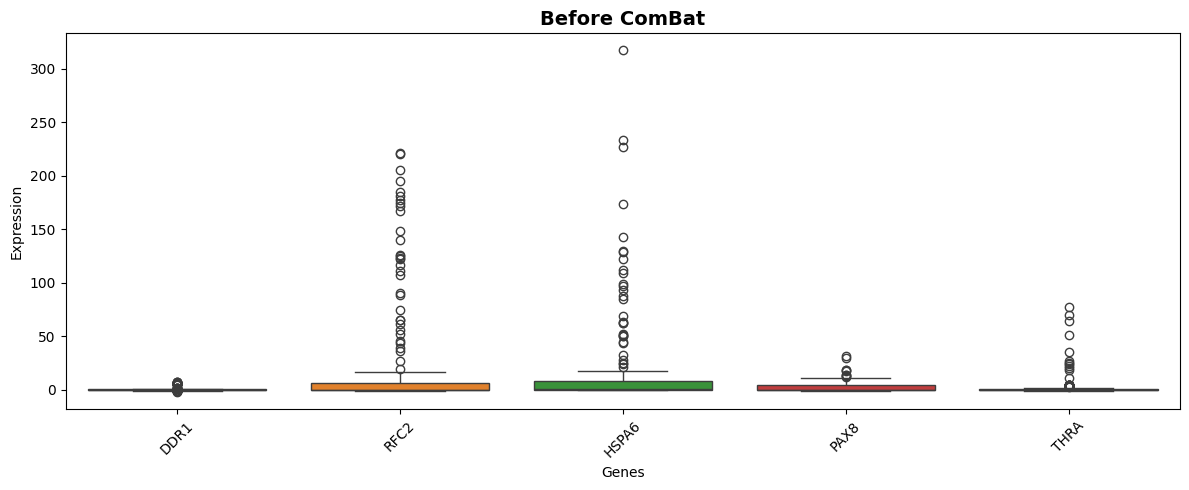

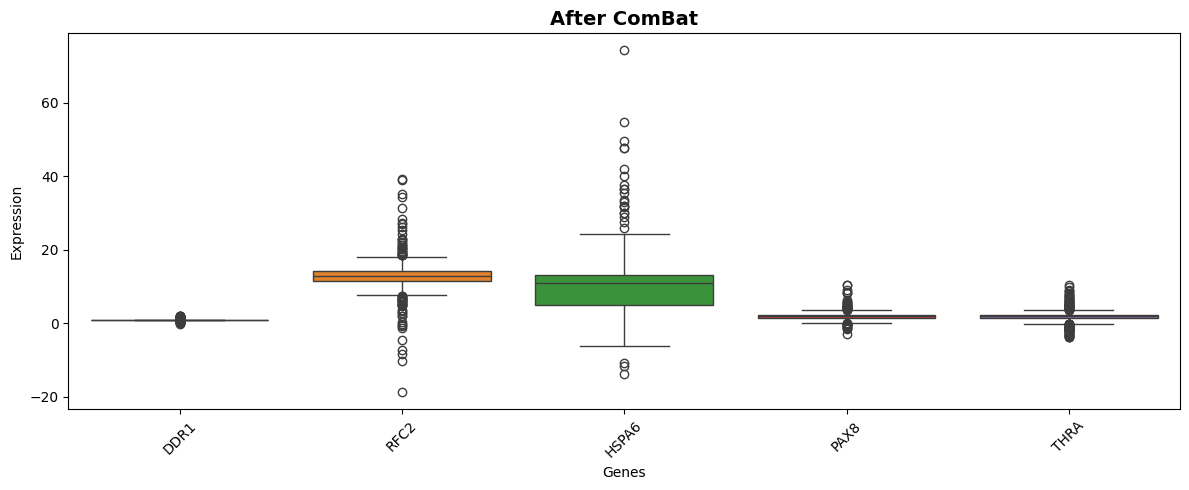

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Select first 5 genes
# ==========================================
sample_genes = X.columns[:5]

# ==========================================
# Before ComBat
# ==========================================
plt.figure(figsize=(12,5))
sns.boxplot(data=X[sample_genes])

plt.title("Before ComBat", fontsize=14, fontweight="bold")
plt.xlabel("Genes")
plt.ylabel("Expression")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ==========================================
# After ComBat
# ==========================================
plt.figure(figsize=(12,5))
sns.boxplot(data=X_corrected[sample_genes])

plt.title("After ComBat", fontsize=14, fontweight="bold")
plt.xlabel("Genes")
plt.ylabel("Expression")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

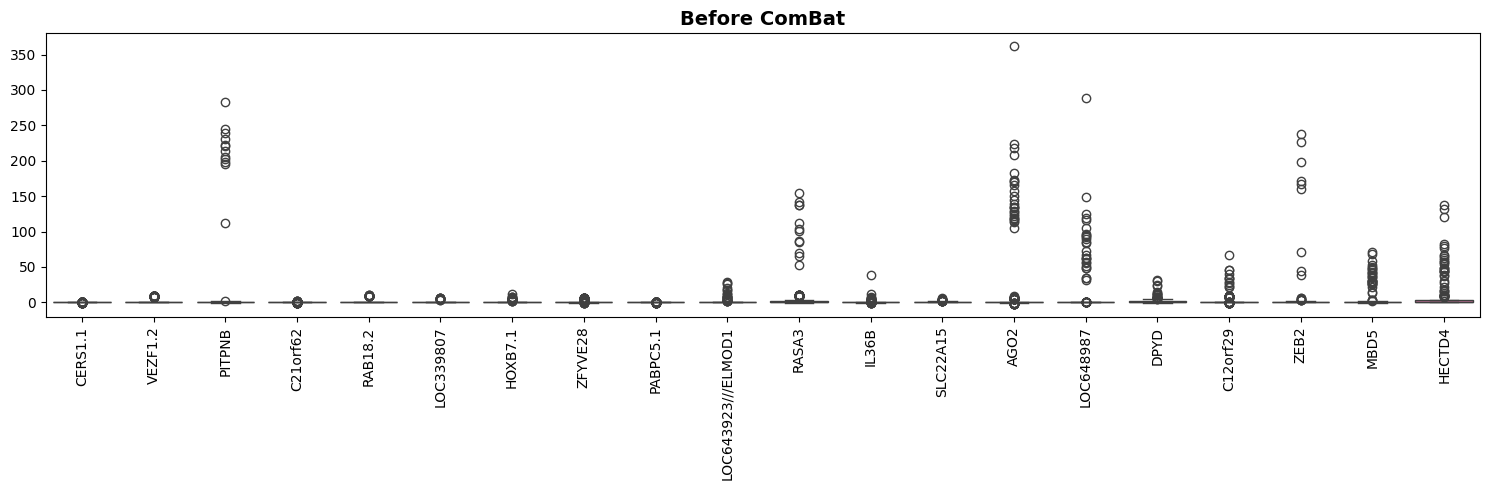

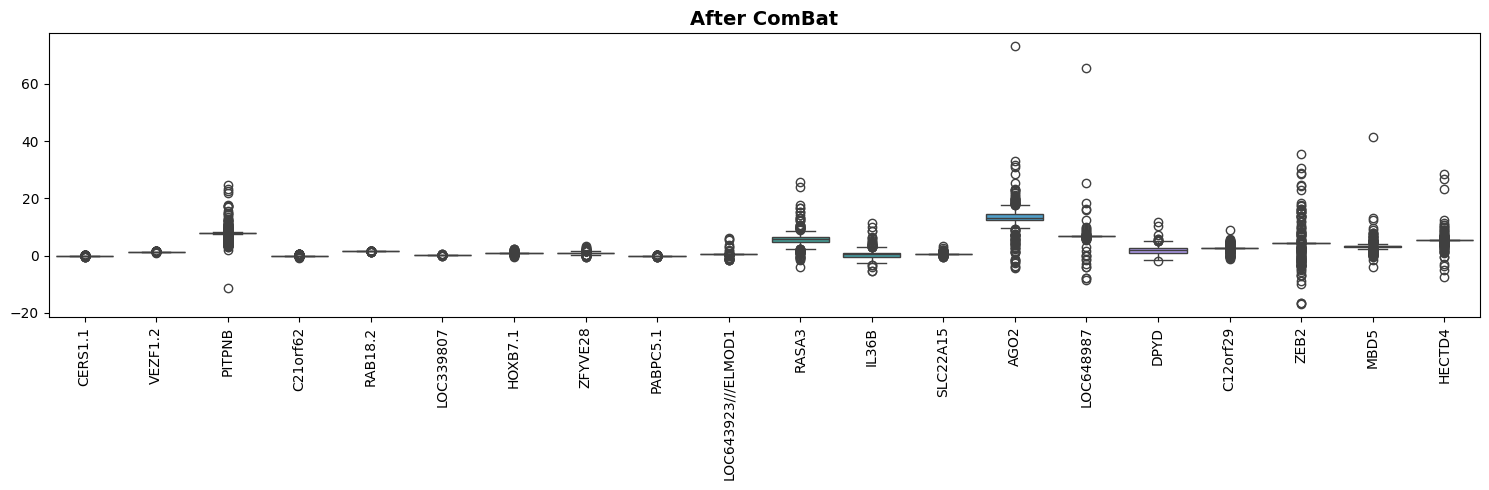

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Randomly select 20 genes
np.random.seed(42)
sample_genes = np.random.choice(X.columns, 20, replace=False)

# Before ComBat
plt.figure(figsize=(15,5))
sns.boxplot(data=X[sample_genes])
plt.title("Before ComBat", fontsize=14, fontweight="bold")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# After ComBat
plt.figure(figsize=(15,5))
sns.boxplot(data=X_corrected[sample_genes])
plt.title("After ComBat", fontsize=14, fontweight="bold")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#Method 3: Batch mixing check

In [17]:
import pandas as pd

# ==========================================
# Create corrected dataframe with Batch info
# ==========================================
corrected_df = X_corrected.copy()
corrected_df["Batch"] = batch.values

# ==========================================
# Mean expression of first 5 genes by Batch
# ==========================================
batch_mean = corrected_df.groupby("Batch").mean(numeric_only=True)

print(batch_mean.iloc[:5, :5])

                                           DDR1       RFC2      HSPA6  \
Batch                                                                   
GSE16463_matrix_Transpose_labeled.csv  0.987622  12.820858  10.956536   
GSE18090_matrix_Transpose_labeled.csv  0.987485  13.194044  11.138255   
GSE28985_matrix_Transpose_labeled.csv  0.988596  12.812933  10.938716   
GSE51808_matrix_Transpose_labeled.csv  0.990400  12.810766  10.934955   
GSE84331_matrix_Transpose_labeled.csv  0.985772  12.743635  10.834478   

                                           PAX8      THRA  
Batch                                                      
GSE16463_matrix_Transpose_labeled.csv  2.076294  1.987101  
GSE18090_matrix_Transpose_labeled.csv  2.079318  1.969606  
GSE28985_matrix_Transpose_labeled.csv  2.075735  1.984374  
GSE51808_matrix_Transpose_labeled.csv  2.075257  1.983023  
GSE84331_matrix_Transpose_labeled.csv  2.078497  2.155246  


In [18]:
import pandas as pd

corrected_df = X_corrected.copy()
corrected_df["Batch"] = batch.values

batch_mean = corrected_df.groupby("Batch").mean(numeric_only=True)

print("Mean expression (first 5 batches × first 5 genes):")
display(batch_mean.iloc[:5, :5])

Mean expression (first 5 batches × first 5 genes):


,DDR1,RFC2,HSPA6,PAX8,THRA
Batch,,,,,
GSE16463_matrix_Transpose_labeled.csv,0.987622,12.820858,10.956536,2.076294,1.987101
GSE18090_matrix_Transpose_labeled.csv,0.987485,13.194044,11.138255,2.079318,1.969606
GSE28985_matrix_Transpose_labeled.csv,0.988596,12.812933,10.938716,2.075735,1.984374
GSE51808_matrix_Transpose_labeled.csv,0.990400,12.810766,10.934955,2.075257,1.983023
GSE84331_matrix_Transpose_labeled.csv,0.985772,12.743635,10.834478,2.078497,2.155246
